# Reporte de Clustering: Análisis de Canciones

Este reporte detalla el proceso de agrupamiento (clustering) realizado sobre el dataset de canciones. El objetivo es identificar grupos naturales de canciones que compartan características de audio similares, lo cual puede ser útil para sistemas de recomendación o categorización automática.

## 1. Preprocesamiento de Datos

Antes de aplicar cualquier algoritmo de clustering, es fundamental preparar los datos. En este caso, hemos realizado los siguientes pasos:

Se han eliminado `artists` y `popularity` para que el agrupamiento se base únicamente en características musicales (audio) y no en el éxito comercial, evitando sesgos que oscurecerían los géneros reales.


1.  **Selección de Características**: Se han seleccionado las columnas numéricas relevantes que describen el audio (`danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`).
2.  **Escalado (StandardScaler)**: Los algoritmos basados en distancia, como K-Means, son muy sensibles a la escala de las variables. Si una variable tiene un rango numérico mucho mayor que otra (ej. `tempo` vs `speechiness`), dominará el cálculo de la distancia. Por ello, hemos estandarizado todas las características para que tengan media 0 y desviación estándar 1. Esto asegura que todas las características contribuyan equitativamente al modelo.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from math import pi
import os

# --- 1. Data Loading & Preprocessing ---

def evaluate_k_means(X, k_range):
    inertias = []
    sil_scores = []
    X_sample = X
    if len(X) > 10000:
        idx = np.random.choice(len(X), 10000, replace=False)
        X_sample = X[idx]
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        labels = kmeans.predict(X_sample)
        score = silhouette_score(X_sample, labels)
        sil_scores.append(score)
        print(f'K={k}: Inercia={kmeans.inertia_:.0f}, Silhouette={score:.4f}')
    return inertias, sil_scores

def calculate_elbow_point(k_range, inertias):
    n_points = len(k_range)
    all_coords = np.vstack((range(n_points), inertias)).T
    first_point = all_coords[0]
    line_vec = all_coords[-1] - all_coords[0]
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = all_coords - first_point
    scalar_product = np.sum(vec_from_first * line_vec_norm, axis=1)
    vec_from_first_parallel = scalar_product[:, np.newaxis] * line_vec_norm
    vec_to_line = vec_from_first - vec_from_first_parallel
    dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))
    idx_of_best_point = np.argmax(dist_to_line)
    return k_range[idx_of_best_point]

try:
    df = pd.read_csv('dataset.csv')
    print('Dataset loaded successfully.')
except FileNotFoundError:
    print('dataset.csv not found. Please ensure the file is in the same directory.')
    # Create dummy data for testing if file missing
    df = pd.DataFrame(np.random.rand(100, 9), columns=['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'])

# Scale data
scaler = StandardScaler()
features_for_clustering = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
# Ensure columns exist
features_for_clustering = [c for c in features_for_clustering if c in df.columns]
X_scaled = scaler.fit_transform(df[features_for_clustering])
df_with_clusters = df.copy()

# Define k_range for clustering
k_range = range(2, 11)




def plot_tsne(X, labels):
    print('Generando visualización t-SNE...')
    # Usar una muestra si el dataset es muy grande para t-SNE
    if len(X) > 5000:
        idx = np.random.choice(len(X), 5000, replace=False)
        X_sample = X[idx]
        labels_sample = labels[idx]
    else:
        X_sample = X
        labels_sample = labels
        
    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X_sample)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=labels_sample, palette='viridis', legend='full')
    plt.title('t-SNE Visualization of Clusters')
    plt.show()


Dataset loaded successfully.


## 2. Reducción de Dimensionalidad y Análisis de Ruido

Para entender mejor la estructura de los datos y eliminar posible redundancia o ruido, realizamos dos análisis previos:

### 2.1. Matriz de Correlación
Analizamos la correlación entre variables para identificar si existen características altamente redundantes. Si dos variables están correlacionadas casi perfectamente, una de ellas podría eliminarse para reducir la dimensionalidad sin perder información significativa.


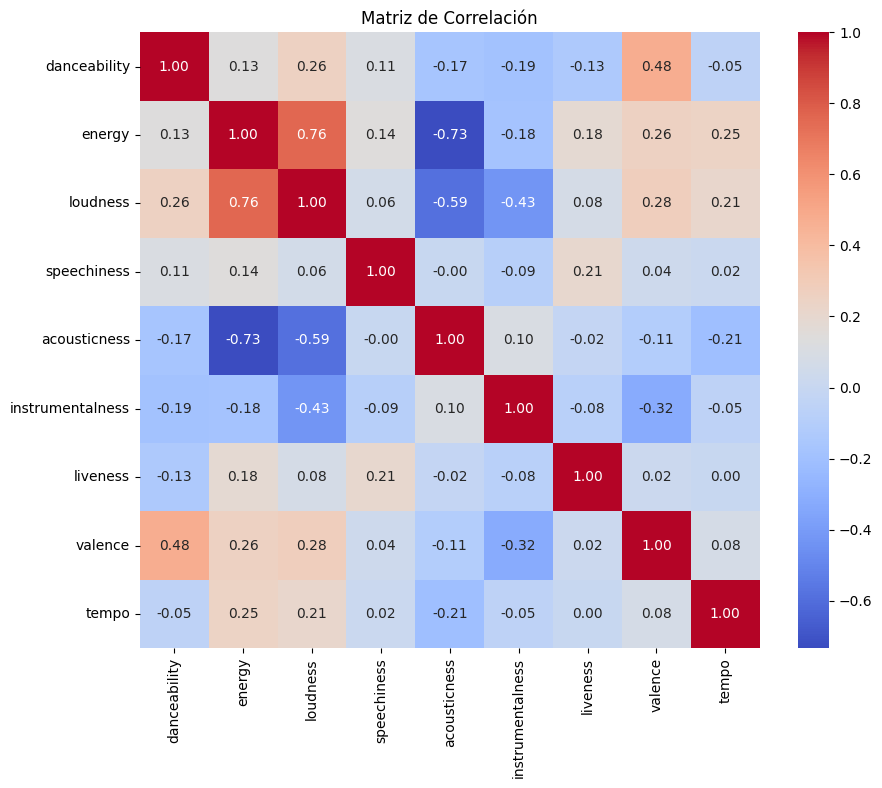

In [31]:
plt.figure(figsize=(10, 8))
corr = df[features_for_clustering].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()



### 2.2. Análisis de Componentes Principales (PCA)
PCA es una técnica de reducción de dimensionalidad que proyecta los datos en un espacio de menor dimensión maximizando la varianza explicada. 

*   **Resultados:** El gráfico de varianza acumulada muestra que se necesitan **6 componentes** para explicar el **90%** de la variabilidad de los datos. Esto indica que la información está distribuida y no concentrada en solo 2 o 3 dimensiones.
*   **Decisión: No usar PCA para el clustering final.**
    *   **Motivo:** Reducir de 9 variables originales a 6 componentes principales no representa una ganancia significativa en simplicidad, pero sí una gran pérdida en **interpretabilidad**. 
    *   **Estrategia:** Alimentaremos al algoritmo K-Means con las 9 características originales escaladas. Esto nos permitirá caracterizar los clusters con términos musicales directos (ej. "Alta Energía") en lugar de componentes abstractas.

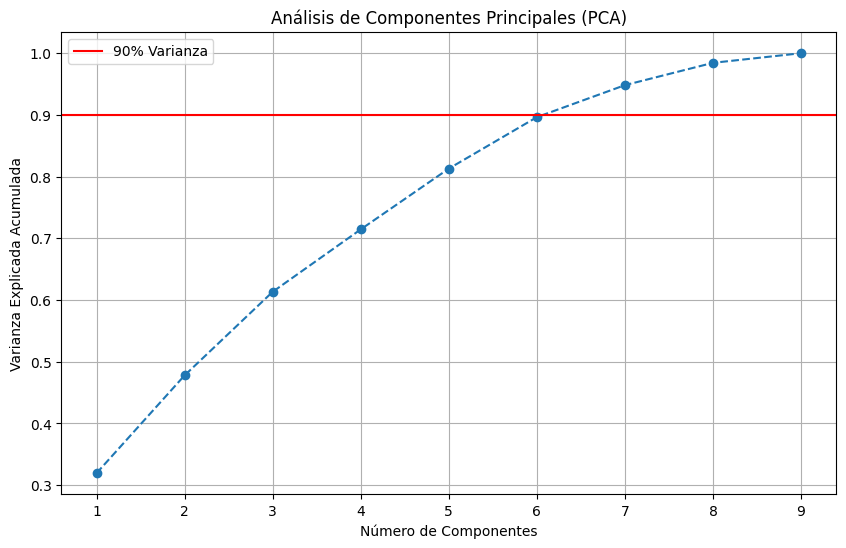

Calculando K-Means para diferentes K...
K=2: Inercia=805673, Silhouette=0.2640
K=3: Inercia=715647, Silhouette=0.1668
K=4: Inercia=646331, Silhouette=0.1731
K=5: Inercia=583441, Silhouette=0.1805
K=6: Inercia=533303, Silhouette=0.1934
K=7: Inercia=484080, Silhouette=0.2016
K=8: Inercia=456282, Silhouette=0.2031
K=9: Inercia=430867, Silhouette=0.1862
K=10: Inercia=413281, Silhouette=0.1714


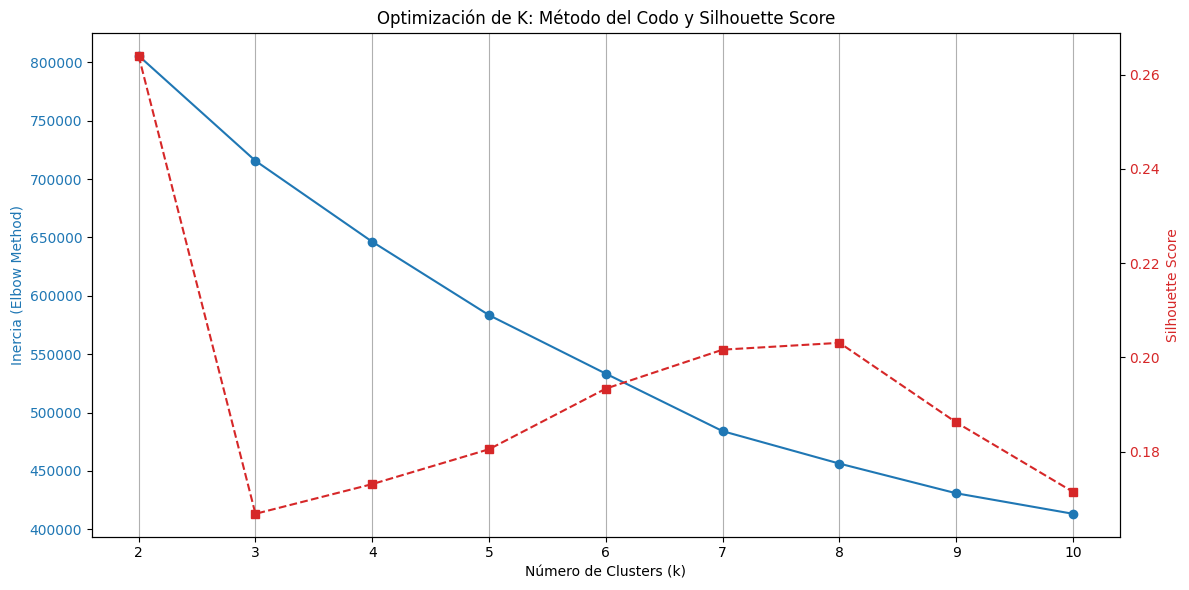

In [44]:
cluster_col = 'cluster'
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Análisis de Componentes Principales (PCA)')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='-', label='90% Varianza')
plt.legend()
plt.show()
components_df = pca


# --- 4. Clustering Logic ---

inertias = []
sil_scores = []
k_range = range(2, 11)

# Sample for silhouette if too large
if len(X_scaled) > 10000:
    idx = np.random.choice(len(X_scaled), 10000, replace=False)
    X_sample = X_scaled[idx]
else:
    X_sample = X_scaled

print('Calculando K-Means para diferentes K...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    labels = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)
    print(f'K={k}: Inercia={kmeans.inertia_:.0f}, Silhouette={score:.4f}')

components_df = inertias, sil_scores
# --- Visualización Combinada: Método del Codo y Silhouette ---
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Elbow Method)', color=color)
ax1.plot(k_range, inertias, 'o-', color=color, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, axis='x')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_scores, 's--', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimización de K: Método del Codo y Silhouette Score')
fig.tight_layout()
plt.show()


### 4.1. Método del Codo (Elbow Method)


En el gráfico de doble eje, mostramos tanto la Inercia (azul) como el Silhouette Score (rojo) para referencia, pero nuestra decisión principal se basará en la estructura de la curva de inercia.

In [46]:
# Calcular K optimo automatico
optimal_k_elbow = calculate_elbow_point(k_range, inertias)

# 3. Train Final Model
print(f'K óptimo sugerido: {optimal_k_elbow}')
k = optimal_k_elbow
print(f'\nEntrenando K-Means con K={k}...')
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters
df_with_clusters, clusters = df, clusters

# --- 5. Cluster Visualization ---
print('Clustering completado.')


K óptimo sugerido: 7

Entrenando K-Means con K=7...
Clustering completado.


## Visualizacion de Clusters

Generando visualización t-SNE...


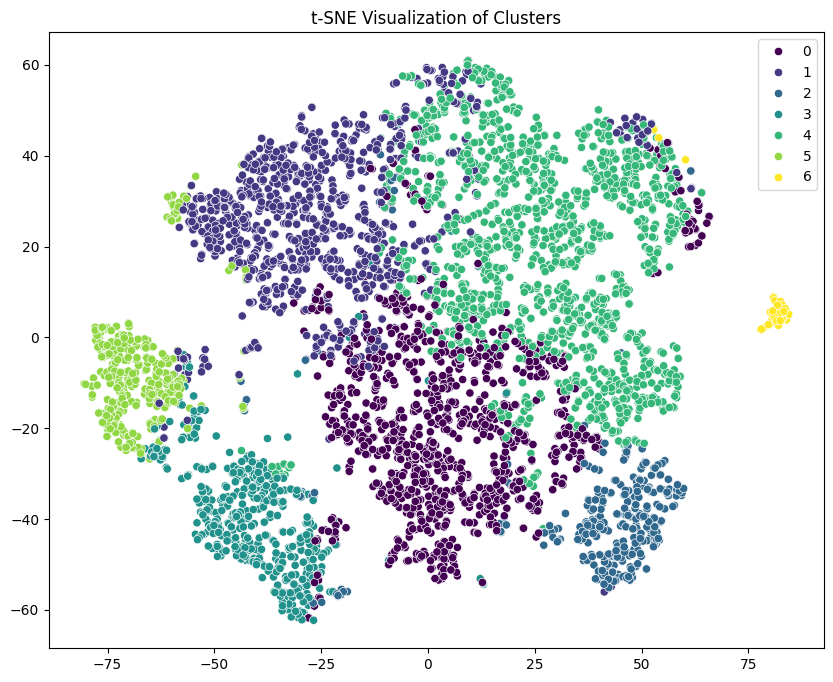

In [47]:

plot_tsne(X_scaled, clusters)


### 4.2. Perfil de los Clusters (Heatmap y Desviación)

Para caracterizar mejor cada cluster, utilizamos dos visualizaciones complementarias:

#### 4.2.1. Heatmap de Valores Estandarizados
Este gráfico muestra el valor promedio de cada característica para cada cluster, pero **estandarizado** (Z-score). 
*   **Rojo (Valores positivos)**: Indica que el cluster tiene un valor *superior* al promedio en esa característica.
*   **Azul (Valores negativos)**: Indica que el cluster tiene un valor *inferior* al promedio.
Esto permite identificar rápidamente los rasgos distintivos de cada grupo sin que las diferencias de escala (ej. tempo vs speechiness) distorsionen la visualización.

Generando Heatmap (Z-Score)...


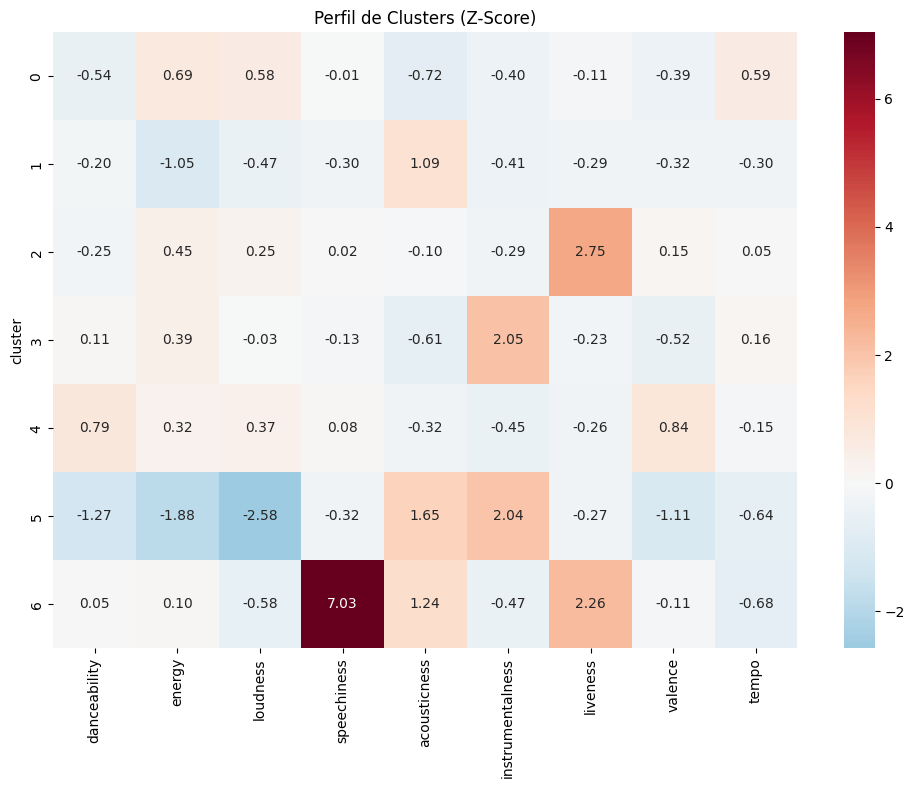

In [48]:
features = features_for_clustering
# Z-Score Heatmap
print('Generando Heatmap (Z-Score)...')
df_z = df.copy()
for col in features:
    df_z[col] = (df[col] - df[col].mean()) / df[col].std()

z_means = df_z.groupby('cluster')[features].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(z_means, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Perfil de Clusters (Z-Score)')
plt.show()
cluster_means = z_means



#### 4.2.2. Gráfico de Desviación Porcentual
Este gráfico muestra cuánto se desvía el promedio de cada cluster respecto al **promedio global** de todo el dataset.
*   Las barras hacia arriba indican que el cluster tiene "más de lo normal" de esa característica.
*   Las barras hacia abajo indican que tiene "menos de lo normal".
Es útil para ver qué hace único a un cluster en comparación con la "canción promedio".

Generando Gráfico de Desviación Porcentual...


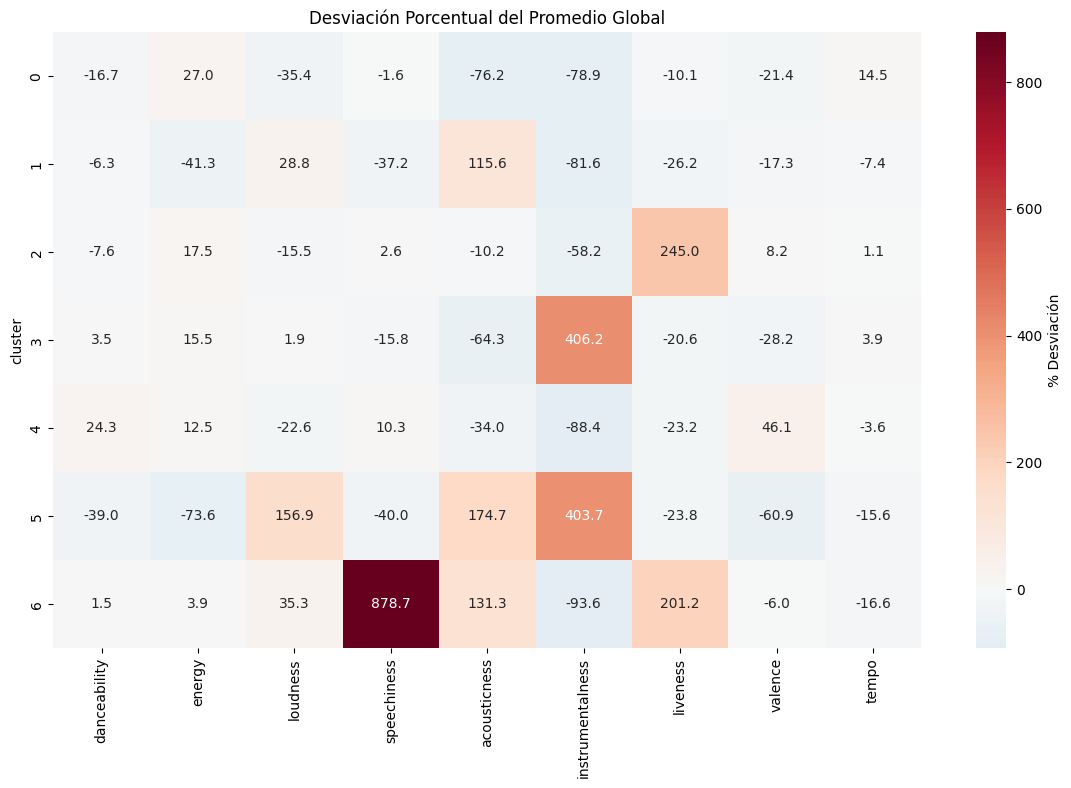

In [49]:

# Percentage Deviation from Global Mean
print('Generando Gráfico de Desviación Porcentual...')
global_means = df[features_for_clustering].mean()
cluster_means = df.groupby('cluster')[features_for_clustering].mean()

deviation = ((cluster_means - global_means) / global_means) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(deviation, annot=True, cmap='RdBu_r', center=0, fmt='.1f', cbar_kws={'label': '% Desviación'})
plt.title('Desviación Porcentual del Promedio Global')
plt.show()



### 4.4. Análisis de Distribución por Cluster (Boxplots)

Para profundizar en la caracterización y validar la utilidad de variables independientes como el `tempo`, visualizamos la distribución de cada característica dentro de cada cluster.

**Hipótesis del Tempo:** Dado que el `tempo` mostró baja correlación general, esperamos ver aquí si ayuda a diferenciar clusters específicos (ej. si un cluster tiene un rango de tempo consistentemente más alto o más bajo que los demás).

C:\Users\Matias\AppData\Local\Temp\ipykernel_28196\1192498688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_with_clusters, palette='viridis')
C:\Users\Matias\AppData\Local\Temp\ipykernel_28196\1192498688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_with_clusters, palette='viridis')
C:\Users\Matias\AppData\Local\Temp\ipykernel_28196\1192498688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_with_clusters, palette='viridis')
C:\U

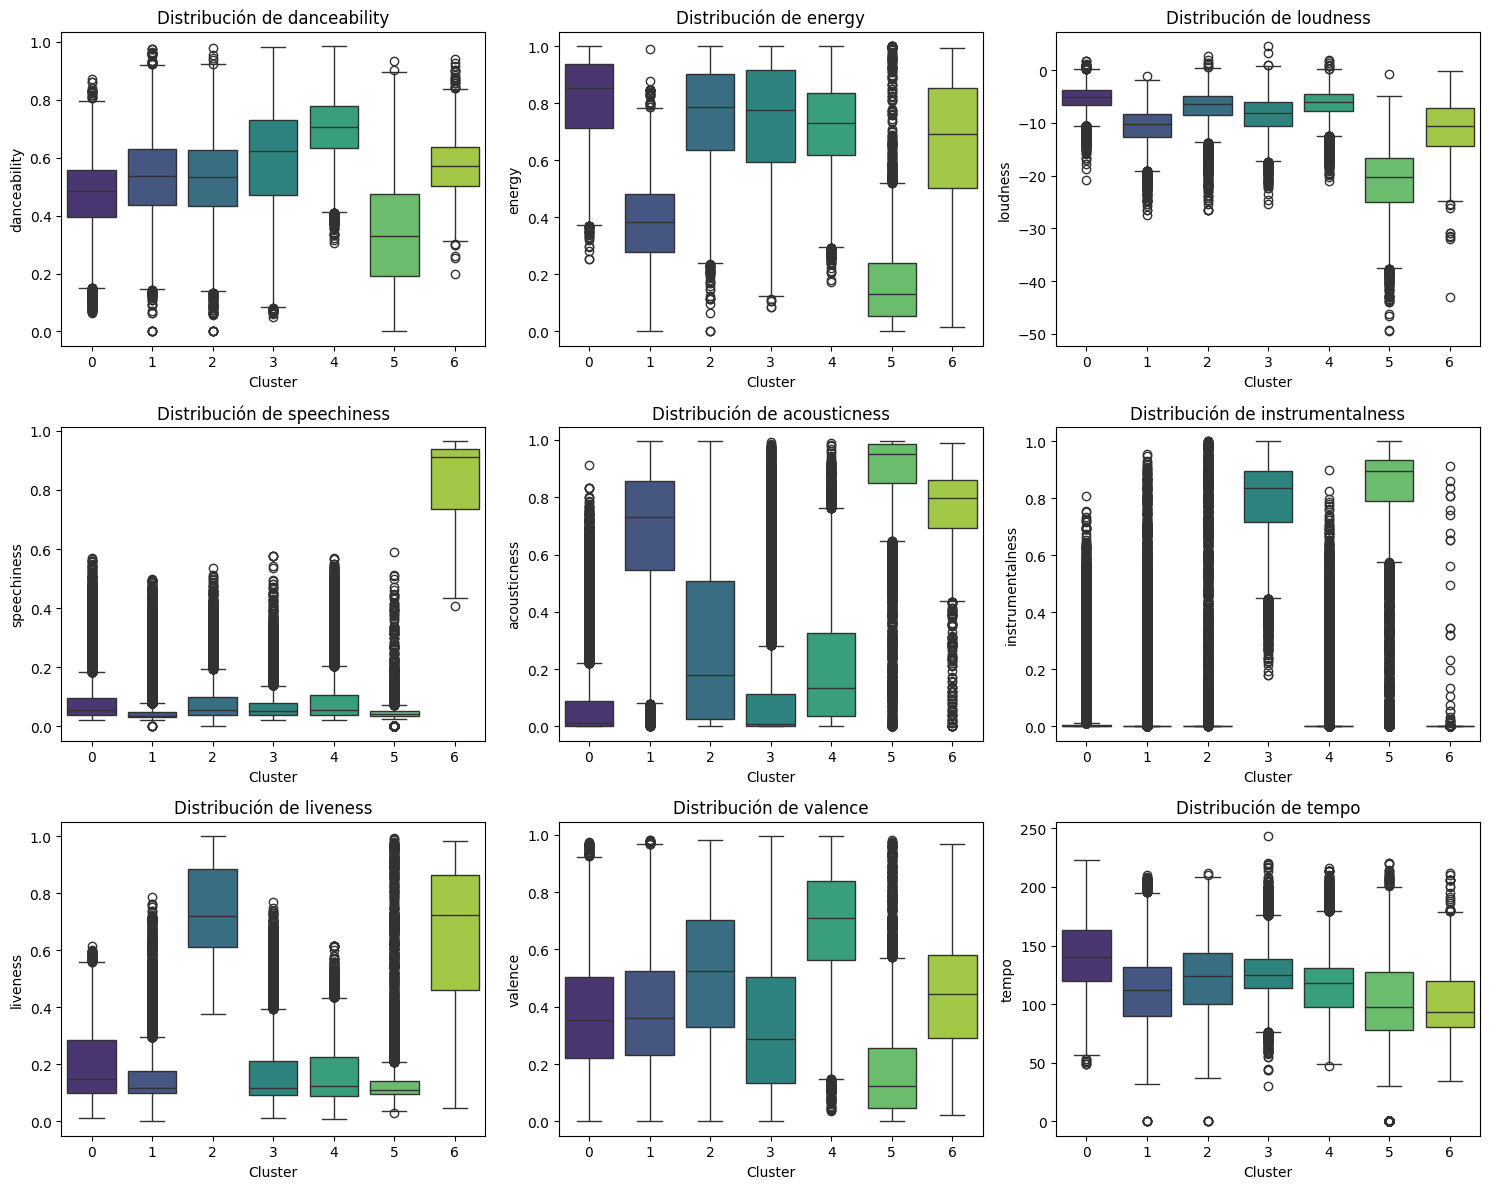

In [50]:
# Configuración de los gráficos
features_to_plot = features_for_clustering
n_features = len(features_to_plot)
n_cols = 3  # Número de columnas en la disposición de gráficos
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, feature in enumerate(features_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    # Se usa df_with_clusters que contiene los datos originales y la columna 'cluster'
    sns.boxplot(x='cluster', y=feature, data=df_with_clusters, palette='viridis')
    plt.title(f'Distribución de {feature}')
    plt.xlabel('Cluster')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

### 4.5. Análisis de Géneros por Cluster

Finalmente, para confirmar nuestras interpretaciones musicales, analizamos los géneros más frecuentes (Top 10) dentro de cada cluster. Esto nos dará la etiqueta definitiva para cada grupo.

C:\Users\Matias\AppData\Local\Temp\ipykernel_28196\3423665113.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
C:\Users\Matias\AppData\Local\Temp\ipykernel_28196\3423665113.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
C:\Users\Matias\AppData\Local\Temp\ipykernel_28196\3423665113.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
C:\Users\Matias\AppDat

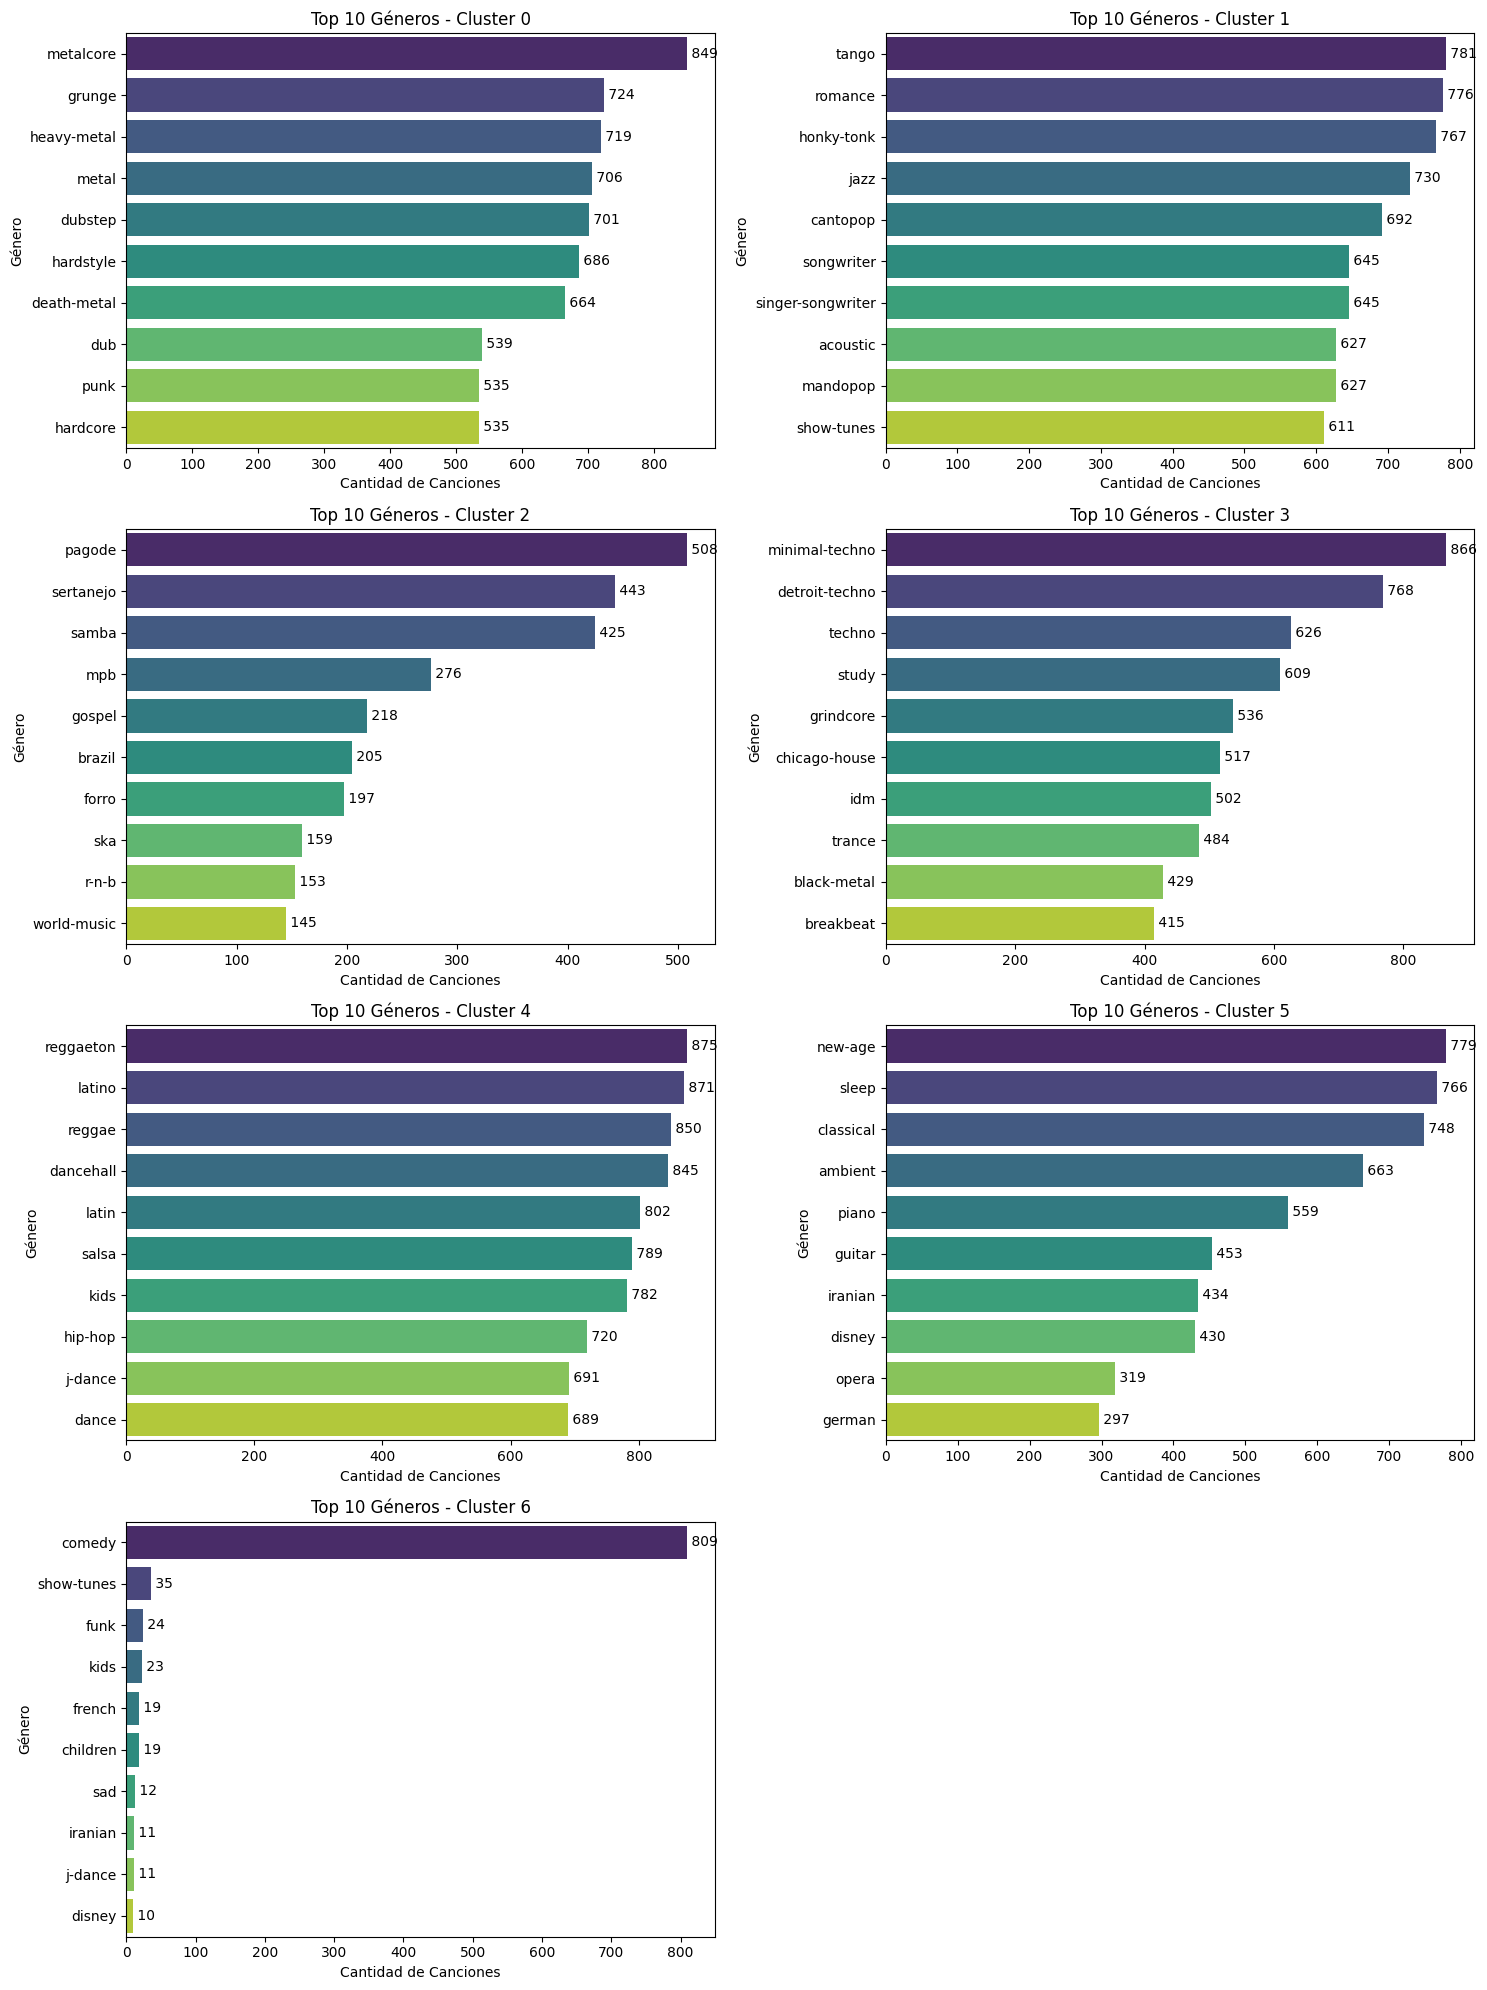

In [42]:
# Configuración de los gráficos
n_clusters = len(df_with_clusters['cluster'].unique())
n_cols = 2
n_rows = (n_clusters + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

# Asumiendo que la columna de género se llama 'track_genre'.
# Si tiene otro nombre (ej. 'genre'), cámbialo aquí:
genre_col = 'track_genre'

for i in range(n_clusters):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Filtrar datos por cluster
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    
    # Contar top 10 géneros
    top_genres = cluster_data[genre_col].value_counts().head(10)
    
    # Crear gráfico de barras
    sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
    
    # Añadir etiquetas de conteo al final de las barras
    for index, value in enumerate(top_genres.values):
        plt.text(value, index, f' {value}', va='center')

    plt.title(f'Top 10 Géneros - Cluster {i}')
    plt.xlabel('Cantidad de Canciones')
    plt.ylabel('Género')

plt.tight_layout()
plt.show()

### Análisis de los Perfiles:

Observando los gráficos de radar y los géneros más frecuentes, podemos etiquetar los clusters de la siguiente manera:

*   **Cluster 0 (Heavy/Metal/Hardcore)**: Este grupo está dominado por géneros intensos y agresivos. Los géneros principales son **metalcore**, **grunge**, **heavy-metal**, **metal**, **dubstep**, **hardstyle**, **death-metal**, **dub**, **punk** y **hardcore**. Es música con alta energía y probablemente tempos rápidos.
*   **Cluster 1 (Melodic/Acoustic/Jazz)**: Un cluster más suave y melódico. Incluye **tango**, **romance**, **honky-tonk**, **jazz**, **cantopop**, **songwriter**, **singer-songwriter**, **acoustic**, **mandopop** y **show-tunes**. Parece agrupar música vocal, acústica y géneros tradicionales o melódicos.
*   **Cluster 2 (Brazilian/Latin)**: Claramente un cluster de música brasileña y latina. Los géneros top son **pagode**, **sertanejo**, **samba**, **mpb** (Música Popular Brasileña), **gospel**, **brazil**, **forro**, **ska**, **r-n-b** y **world-music**.
*   **Cluster 3 (Electronic/Techno)**: Música electrónica y repetitiva. Destacan **minimal-techno**, **detroit-techno**, **techno**, **study**, **grindcore**, **chicago-house**, **idm**, **trance**, **black-metal** y **breakbeat**. Es probable que este grupo tenga alta instrumentalidad y tempos constantes.
*   **Cluster 4 (Latin/Reggaeton/Dance)**: El cluster de la fiesta latina y el baile. Dominado por **reggaeton**, **latino**, **reggae**, **dancehall**, **latin**, **salsa**, **kids**, **hip-hop**, **j-dance** y **dance**. Son géneros con alta bailabilidad y energía.
*   **Cluster 5 (Relax/Ambient/Classical)**: Música para relajarse o dormir. Incluye **new-age**, **sleep**, **classical**, **ambient**, **piano**, **guitar**, **iranian**, **disney**, **opera** y **german**. Probablemente caracterizado por baja energía y alta acusticidad.
*   **Cluster 6 (Comedy/Speech)**: Un cluster atípico dominado masivamente por **comedy**. También aparecen **show-tunes**, **funk**, **kids**, **french**, **children**, **sad**, **iranian**, **j-dance** y **disney**, pero la comedia es el factor distintivo principal, sugiriendo un alto contenido de 'speechiness'.